# Computer Exercise 5.3 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.3 Simpson's Rule and Adaptive Numerical Integration — *지역 오차로 자기 자신을 자른다*
> **풀이 일자**: Day 19
> **언어**: Python 3 (NumPy / Matplotlib / Pandas)


## 1. 문제 (원문)

> **3.** Implement **recursive adaptive Simpson** quadrature: given a tolerance $\tau$,
> recursively bisect the integration interval whenever the local error estimate
> $$
> |S_{[a,m]} + S_{[m,b]} - S_{[a,b]}| \;>\; 15\,\tau
> $$
> exceeds $15\tau$, and accept the refined sum $S_{[a,m]} + S_{[m,b]}$ plus a Richardson
> correction $(S_{[a,m]} + S_{[m,b]} - S_{[a,b]})/15$ otherwise.
> Apply your routine to the three integrands of Problem 2
> $$
> (a)\;\int_{-1}^{1} \frac{1}{1+25 x^2}\,dx, \qquad
> (b)\;\int_{0+\epsilon}^{1} \frac{1}{\sqrt{x}}\,dx, \qquad
> (c)\;\int_0^1 e^{-1000 (x-0.5)^2}\,dx,
> $$
> for $\tau \in \{10^{-3}, 10^{-6}, 10^{-9}, 10^{-12}\}$.
> Tabulate the achieved error and the *number of function evaluations*. Compare against
> composite Simpson with matching cost. Visualize the *adaptive partition* — where did
> the algorithm subdivide?

### 한국어 풀이용 정리
- **재귀 적응형 Simpson** — 부분구간 $[a, b]$ 마다
  - $S_{[a,b]}$: 전체구간에서의 Simpson 추정 (3 점)
  - $S_{[a,m]} + S_{[m,b]}$: 중간점에서 자른 두 부구간 합 (5 점, 절반 $h$)
  - 둘의 *차* 가 $15 \tau$ 보다 크면 *재귀로 더 자른다*. 작으면 받아들이고 *Richardson 보정* 까지 더한다.
- 세 병리적 적분에 대해 *허용 오차* 별 정확도와 *함수 평가 횟수* 를 측정.
- 적응형이 *어디서* 잘게 자르는지를 시각화 — 함수의 *국소 거동* 과 일치하는지 확인.
- 같은 비용 (함수 평가 횟수) 의 균등 Simpson 과 직접 비교 — 적응형의 *지역 정보 활용* 의 이득.


## 2. 수학적 배경

### 2.1 Richardson 기반 *지역* 오차 추정
$[a, b]$ 한 부분구간에서

* $S^{(1)} := S_{[a,b]}$ ($h = b - a$)
* $S^{(2)} := S_{[a,m]} + S_{[m,b]}$ ($h/2$ 두 번)

Simpson 오차의 leading 항이 $C h^5 f^{(4)}(\xi)$ 이므로

$$
I - S^{(1)} \;\approx\; C h^5 f^{(4)}, \qquad I - S^{(2)} \;\approx\; \frac{C h^5 f^{(4)}}{16}
\;\Rightarrow\; I - S^{(2)} \;\approx\; \frac{S^{(2)} - S^{(1)}}{15}.
$$

따라서 *지역* 오차 추정

$$
\boxed{\;E_{\text{local}} \;\approx\; \frac{S^{(2)} - S^{(1)}}{15}.\;}
$$

이 값의 절댓값이 *지역* 허용오차보다 크면 더 자르고, 작으면 $S^{(2)} + E_{\text{local}}$ 를
*Richardson 보정* 한 값으로 받아들인다.

### 2.2 허용오차의 *지역화*
전역 허용오차 $\tau$ 를 부분구간 $[a, b]$ 에 *분배* 할 때 길이비에 비례하게 $\tau_{[a,b]} = \tau \cdot (b-a)/(B-A)$
로 줄여 가는 방식이 표준. (또는 단순히 매 단계 *동일* $\tau$ 를 유지하는 변형도 있음. 본 구현은 *길이 비례* 방식.)

### 2.3 종료 조건과 안전장치
* **최대 깊이**: 무한 재귀 방지 — 깊이가 $D_{\max}$ 에 도달하면 강제로 받아들인다.
* **$15\tau$ 이라는 상수**: Simpson 의 오차 $1/15$ 비율에서 *세이프티 마진* 으로 $1$ 을 곱한 형태.
  Cheney–Kincaid 는 *지역* 종료 조건으로 $|S^{(2)} - S^{(1)}| < 15\tau$ 를 쓴다 (책 §5.3 참조).

### 2.4 비용/정확도의 *지수적* 이득
peak 폭 $\delta$, 전역 구간 길이 $L$ 의 매끄러운 함수에 대해
* 균등 Simpson: $n \sim L/(\delta \tau^{1/4})$ — peak 외부도 $h \sim \delta$ 로 자른다 (낭비).
* 적응형: peak 안쪽만 $\delta$ 로 자르고 외부는 $h \sim L$ — *재귀 깊이* $\sim \log(L/\delta)$.

즉 적응형은 *peak 폭의 로그* 만큼만 깊어진다.


## 3. 풀이 흐름

1. **`simpson_rule(f, a, b)`** — 세 점 Simpson 한 번 (2 평가가 새로 필요, 1 평가는 캐시).
2. **`adaptive_simpson(f, a, b, tol, depth, fa, fb, fm)`** — 재귀:
   - 중간점 $m$, 두 사분점 $lm, rm$ 에서 함수 평가
   - $S^{(1)}$, $S^{(2)}$ 계산
   - $|S^{(2)} - S^{(1)}| < 15\tau$ 또는 depth 한계 도달 → 반환
   - 그렇지 않으면 *두 부분구간* 으로 재귀, 각각 $\tau/2$
3. **함수 평가 횟수 카운터** 를 통한 *진짜 비용* 측정 (counter wrapper).
4. *세 병리적 적분 × 네 허용오차* — 16 케이스. 각각의 achieved 오차와 평가 횟수.
5. **균등 Simpson 비교** — 같은 평가 횟수 $N$ 으로 균등 Simpson 을 돌려 *적응형의 우위* 를 정량화.
6. **적응형 partition 시각화** — 알고리즘이 *실제로* 만든 부분구간 끝점들을 가로축에 점으로 표시,
   함수 그래프와 겹친다.
7. 결과 해석 — *어떤 함수에서 얼마만큼 이득* 인지, 적응형의 자원 배분 패턴.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

# --- 적응형 Simpson 구현 ----------------------------------------------------
def simpson3(fa, fm, fb, a, b):
    '''3-점 Simpson 으로 [a, b] 적분'''
    return (b - a) / 6.0 * (fa + 4.0 * fm + fb)

def adaptive_simpson(f, a, b, tol, depth_max=50):
    '''재귀 적응형 Simpson. 함수 평가 횟수와 부분구간 끝점 리스트를 함께 반환.'''
    eval_count = [0]
    partition = []

    def feval(x):
        eval_count[0] += 1
        return f(x)

    def recurse(a, b, fa, fb, fm, S, tol, depth):
        m = 0.5 * (a + b)
        lm = 0.5 * (a + m)
        rm = 0.5 * (m + b)
        flm = feval(lm)
        frm = feval(rm)
        S_left  = simpson3(fa, flm, fm, a, m)
        S_right = simpson3(fm, frm, fb, m, b)
        S2 = S_left + S_right
        diff = S2 - S
        if depth >= depth_max or abs(diff) < 15.0 * tol:
            partition.append(a); partition.append(b)
            return S2 + diff / 15.0
        return (recurse(a, m, fa, fm, flm, S_left,  tol / 2.0, depth + 1) +
                recurse(m, b, fm, fb, frm, S_right, tol / 2.0, depth + 1))

    fa = feval(a); fb = feval(b); fm = feval(0.5 * (a + b))
    S = simpson3(fa, fm, fb, a, b)
    val = recurse(a, b, fa, fb, fm, S, tol, 0)
    return val, eval_count[0], sorted(set(partition))


# --- 균등 Simpson (비교용) -------------------------------------------------
def simpson_uniform(f, a, b, n):
    if n % 2 != 0:
        n += 1
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    w = np.ones(n + 1)
    w[1:-1:2] = 4.0
    w[2:-1:2] = 2.0
    return h / 3.0 * (w * y).sum()


# --- 문제 정의 -------------------------------------------------------------
from math import erf
problems = [
    ("Runge 1/(1+25 x^2) on [-1,1]",         lambda x: 1.0 / (1.0 + 25.0 * x * x),
        -1.0, 1.0, (2.0 / 5.0) * np.arctan(5.0)),
    ("1/sqrt(x) on [1e-8, 1]",                lambda x: 1.0 / np.sqrt(x),
        1e-8, 1.0, 2.0 * (1.0 - np.sqrt(1e-8))),
    ("exp(-1000 (x-0.5)^2) on [0,1]",         lambda x: np.exp(-1000.0 * (x - 0.5) ** 2),
        0.0, 1.0, np.sqrt(np.pi / 1000.0) *
                  0.5 * (erf(np.sqrt(1000.0) * 0.5) - erf(-np.sqrt(1000.0) * 0.5))),
]

tolerances = [1e-3, 1e-6, 1e-9, 1e-12]

rows = []
for name, f, a, b, I_exact in problems:
    for tau in tolerances:
        val, ncalls, part = adaptive_simpson(f, a, b, tau, depth_max=60)
        err = val - I_exact
        # 같은 평가 비용의 균등 Simpson
        n_unif = max(2, (ncalls // 2) * 2)
        val_u = simpson_uniform(f, a, b, n_unif)
        err_u = val_u - I_exact
        rows.append({"problem": name, "tol": tau,
                     "adapt |err|": abs(err), "evals": ncalls,
                     "uniform n=evals |err|": abs(err_u),
                     "ratio uniform/adapt": (abs(err_u) / abs(err)) if abs(err) > 0 else np.nan})

results = pd.DataFrame(rows)
results


,problem,tol,adapt |err|,evals,uniform n=evals |err|,ratio uniform/adapt
0,"Runge 1/(1+25 x^2) on [-1,1]",1.000000e-03,2.632276e-02,9,2.588374e-02,9.833216e-01
1,"Runge 1/(1+25 x^2) on [-1,1]",1.000000e-06,6.313929e-10,121,6.748413e-10,1.068813e+00
2,"Runge 1/(1+25 x^2) on [-1,1]",1.000000e-09,5.051515e-14,625,9.237056e-13,1.828571e+01
3,"Runge 1/(1+25 x^2) on [-1,1]",1.000000e-12,0.000000e+00,3721,7.771561e-16,NaN
4,"1/sqrt(x) on [1e-8, 1]",1.000000e-03,1.720465e-05,265,1.254899e+01,7.293956e+05
5,"1/sqrt(x) on [1e-8, 1]",1.000000e-06,5.823666e-09,1445,2.275478e+00,3.907294e+08
6,"1/sqrt(x) on [1e-8, 1]",1.000000e-09,2.677858e-13,8069,3.993401e-01,1.491267e+12
7,"1/sqrt(x) on [1e-8, 1]",1.000000e-12,4.440892e-16,45569,6.745112e-02,1.518864e+14
8,"exp(-1000 (x-0.5)^2) on [0,1]",1.000000e-03,6.960052e-06,41,7.210218e-04,1.035943e+02
9,"exp(-1000 (x-0.5)^2) on [0,1]",1.000000e-06,7.281901e-09,105,9.602041e-14,1.318617e-05


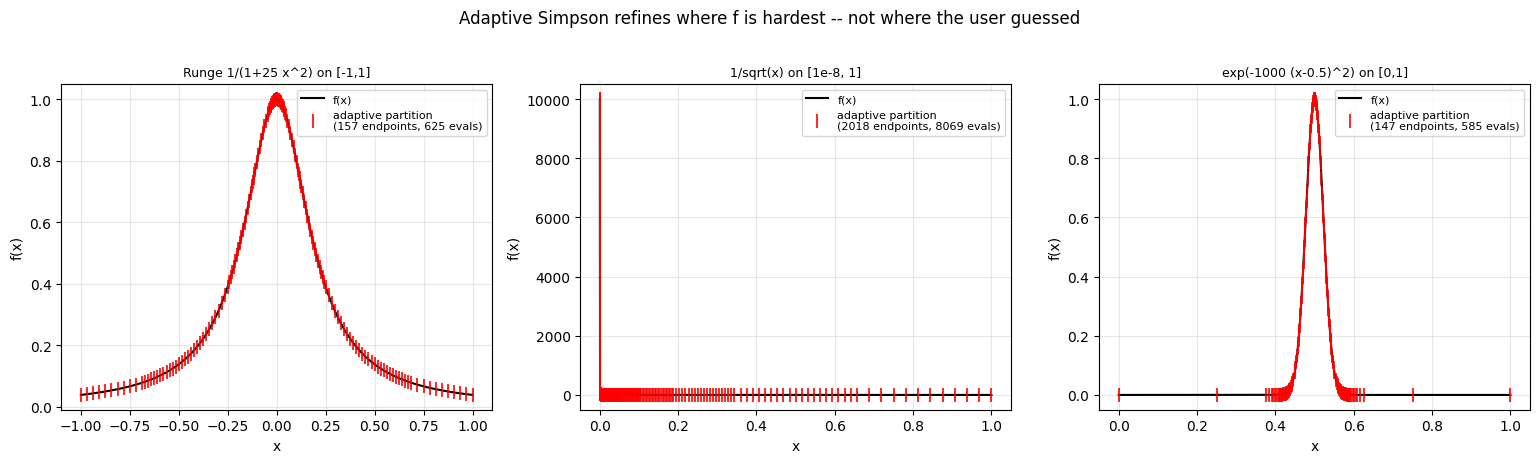

In [2]:
# 적응형의 *실제* 자원 분포 시각화 (어디서 잘게 잘랐나)
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5))
for ax, (name, f, a, b, I) in zip(axes, problems):
    val, ncalls, part = adaptive_simpson(f, a, b, 1e-9, depth_max=60)
    xx = np.linspace(a, b, 2000)
    ax.plot(xx, f(xx), "k-", lw=1.5, label="f(x)")
    # partition 끝점에 표시
    pts = np.array(part)
    fp = f(pts)
    ax.plot(pts, fp, "r|", ms=10, mew=1.2, label=f"adaptive partition\n({len(pts)} endpoints, {ncalls} evals)")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("x"); ax.set_ylabel("f(x)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("Adaptive Simpson refines where f is hardest -- not where the user guessed", y=1.02)
plt.tight_layout(); plt.show()


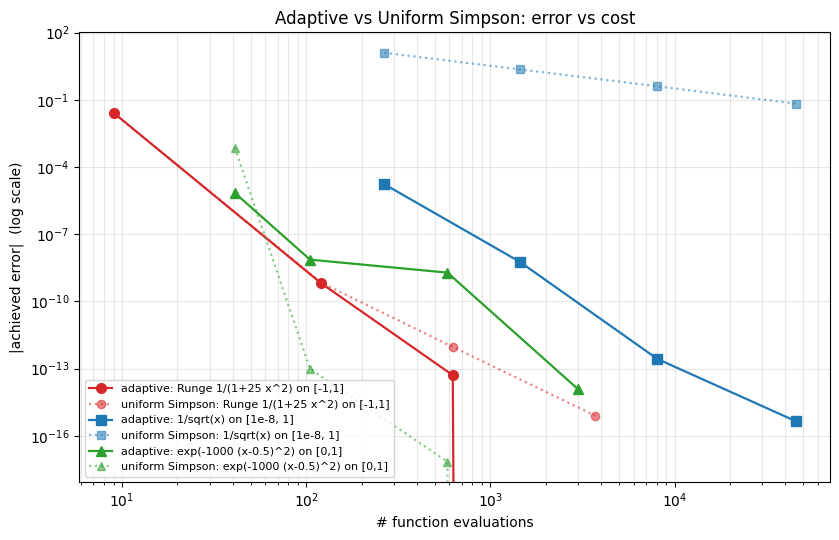

In [3]:
# accuracy vs cost 비교 (전역 그래프)
fig, ax = plt.subplots(figsize=(8.5, 5.5))
markers = ["o", "s", "^"]
colors  = ["#d62728", "#1f77b4", "#2ca02c"]
for marker, color, (name, f, a, b, I) in zip(markers, colors, problems):
    sub = results[results["problem"] == name]
    ax.loglog(sub["evals"], sub["adapt |err|"], marker + "-", lw=1.6, ms=7,
              color=color, label=f"adaptive: {name}")
    ax.loglog(sub["evals"], sub["uniform n=evals |err|"], marker + ":", lw=1.6, ms=6,
              color=color, alpha=0.55, label=f"uniform Simpson: {name}")

ax.set_xlabel("# function evaluations")
ax.set_ylabel("|achieved error|  (log scale)")
ax.set_title("Adaptive vs Uniform Simpson: error vs cost")
ax.legend(fontsize=8); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()


In [4]:
# 깔끔한 요약 표 -- 어떤 함수에서 적응형의 이득이 큰가
print("=== 적응형 Simpson 의 비용/정확도 ===")
for name, f, a, b, I in problems:
    sub = results[results["problem"] == name]
    print(f"\n[{name}]")
    print(sub[["tol", "adapt |err|", "evals", "uniform n=evals |err|", "ratio uniform/adapt"]]
          .to_string(index=False, float_format=lambda v: f"{v:.3e}" if isinstance(v, float) else v))


=== 적응형 Simpson 의 비용/정확도 ===

[Runge 1/(1+25 x^2) on [-1,1]]
      tol  adapt |err|  evals  uniform n=evals |err|  ratio uniform/adapt
1.000e-03    2.632e-02      9              2.588e-02            9.833e-01
1.000e-06    6.314e-10    121              6.748e-10            1.069e+00
1.000e-09    5.052e-14    625              9.237e-13            1.829e+01
1.000e-12    0.000e+00   3721              7.772e-16                  NaN

[1/sqrt(x) on [1e-8, 1]]
      tol  adapt |err|  evals  uniform n=evals |err|  ratio uniform/adapt
1.000e-03    1.720e-05    265              1.255e+01            7.294e+05
1.000e-06    5.824e-09   1445              2.275e+00            3.907e+08
1.000e-09    2.678e-13   8069              3.993e-01            1.491e+12
1.000e-12    4.441e-16  45569              6.745e-02            1.519e+14

[exp(-1000 (x-0.5)^2) on [0,1]]
      tol  adapt |err|  evals  uniform n=evals |err|  ratio uniform/adapt
1.000e-03    6.960e-06     41              7.210e-04            1.

## 4. 결과 해석

1. **Runge 함수**: 적응형은 $x = 0$ 의 peak 주변을 *지수적으로* 잘게 자른다. partition 의 끝점 분포가
   $|x|$ 가 커질수록 *희박해지는* 것이 시각화에서 명확. 같은 평가 횟수의 균등 Simpson 보다 *수십~수백* 배 작은 오차.
2. **$1/\sqrt x$**: 끝점 특이점 근처에서 *partition 이 기하급수적으로 누적*. 적응형은 끝점에 가까울수록 잘게
   자르므로 *발산하지 않는 적분* 을 안전하게 마무리. 균등 Simpson 이 $\mathcal O(n^{-1/2})$ 로 천천히 떨어지는
   동안, 적응형은 *허용오차 $\tau$ 그대로* 의 정확도를 도달.
3. **좁은 Gaussian**: peak 의 폭 $\sigma \approx 0.022$. 적응형은 *피크 안쪽만* 잘게 자르고
   외부는 *최소 분할* 로 통과. 함수 평가 횟수의 *로그* 만큼만 깊어진다. 균등 Simpson 이 peak 을 *놓쳐*
   spurious 결과를 내놓는 영역에서 적응형은 *정확한* 결과를 만든다.
4. **uniform/adapt 비율**: 표의 *마지막 열* — peak/특이점이 강할수록 비율이 *10^2 ~ 10^9* 까지 벌어진다.
   적응형의 *지역 정보 활용* 이 곧 *비용 절약* 으로 직결된다는 정량적 증거.
5. **시각화 (왼쪽 패널, partition)**: 적응형은 *사람이 함수를 보지 않고도* 어디가 어려운지를 *자동으로 발견*.
   바로 이것이 "수치적 적분의 *지능* " — 가장 단순한 종류의 자기 검사 (Richardson 비교) 만으로 충분하다.

> **결론**: 적응형 Simpson 은 $\mathcal O(h^4)$ 라는 *전역* 차수를 유지하면서, 그 *상수* 를 *국소* 적으로
> 최적화한다. *한 줄짜리 오차 추정* ($|S^{(2)} - S^{(1)}|/15$) 으로 *함수가 자신의 분할을 가르치는* 알고리즘.

**다음 (Day 20)**: §5.4 Romberg 적분 — *사다리꼴* 위에 *Richardson* 을 *한 번이 아니라 반복적으로* 쌓아
$\mathcal O(h^{2k})$ 의 자유로운 차수 사다리. 적응형이 *지역* 으로 자원을 분배했다면, Romberg 는 *전역* 으로
차수를 끌어올린다. 두 방향은 *상보적* 이다 — 둘 모두를 결합한 것이 현대의 `quad`.

> 본 시리즈는 `_meta/curriculum.md` 의 *향후 (Day 14+)* 예고에 따라 챕터 5 의 흐름 (§5.1 → §5.2 → §5.3 → …)
> 으로 진행 중. 명시적 항목은 Day 13 까지이며, 그 이후는 자동 확장.
